<a href="https://colab.research.google.com/github/Shomokcs/-A-algorithm/blob/main/Defensethon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
# 1. تثبيت المكتبات اللازمة
!pip install -q inference-sdk opencv-python-headless

import cv2
import numpy as np
from google.colab import files
from inference_sdk import InferenceHTTPClient
from google.colab.patches import cv2_imshow


In [63]:
# 2. إعداد الاتصال بموديل قصاص
API_KEY = "CydqsXFmHt46jh2f43mm" # مفتاحك الخاص
PROJECT_ID = "my-first-project-6b15j/1"
CLIENT = InferenceHTTPClient(api_url="https://serverless.roboflow.com", api_key=API_KEY)


In [64]:
# 3. دالة تحسين الصورة (Image Enhancement)
def enhance_image(img):
    # تحسين التباين (Contrast) لبروز الأثر في الرمل
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced_img = cv2.merge((cl,a,b))
    enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_LAB2BGR)
    # تقليل الضجيج وتوضيح الحواف
    enhanced_img = cv2.detailEnhance(enhanced_img, sigma_s=10, sigma_r=0.15)
    return enhanced_img


In [65]:
PIXEL_TO_CM = 0.04

In [68]:
# 5. رفع الصورة
# =========================
print("🚀 Upload footprint image")
uploaded = files.upload()


🚀 Upload footprint image


Saving 360_F_118264007_4G6xX4wTzRzyJC9igUL6V1fMOy7EiBrd.jpg to 360_F_118264007_4G6xX4wTzRzyJC9igUL6V1fMOy7EiBrd (2).jpg



🔍 Running footprint detection...

Confidence : 0.82
Foot Length: 9.60 cm
Foot Width : 3.72 cm
EU Size    : 17
Category   : Small Foot

🖼️ Output Image:


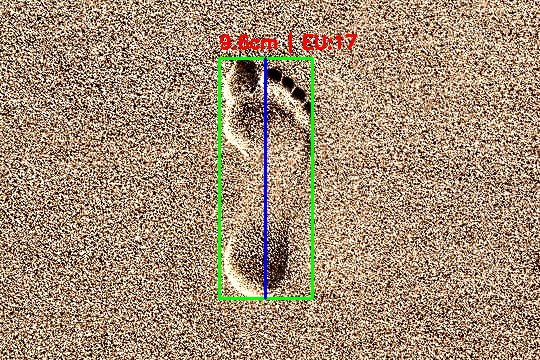

In [69]:
# =========================
# 6. المعالجة والتحليل
# =========================
for filename in uploaded.keys():

    img = cv2.imread(filename)
    enhanced = enhance_image(img)

    enhanced_path = "enhanced_" + filename
    cv2.imwrite(enhanced_path, enhanced)

    print("\n🔍 Running footprint detection...")

    result = CLIENT.infer(enhanced_path, model_id=PROJECT_ID)

    if not result["predictions"]:
        print("⚠️ No footprint detected.")
        continue

    # 🔥 (تعديل 1) ← نقل هذا اللوب للداخل
    for pred in result["predictions"]:

        if pred["confidence"] < 0.3:
            continue

        # =========================
        # القياسات
        # =========================
        width_px = pred["width"]
        height_px = pred["height"]

        length_px = max(width_px, height_px)
        width_px = min(width_px, height_px)

        length_cm = length_px * PIXEL_TO_CM
        width_cm = width_px * PIXEL_TO_CM

        # 🔥 (تعديل 2) ← إضافة EU size
        eu_size = round((length_cm + 1.5) * 1.5)

        # =========================
        # التصنيف
        # =========================
        if length_cm < 23.5:
            category = "Small Foot"
        elif length_cm <= 26.5:
            category = "Medium Foot"
        else:
            category = "Large Foot"

        # =========================
        # الطباعة
        # =========================
        # 🔥 (تعديل 3) ← تصحيح indentation
        print("\n====================")
        print(f"Confidence : {pred['confidence']:.2f}")
        print(f"Foot Length: {length_cm:.2f} cm")
        print(f"Foot Width : {width_cm:.2f} cm")
        print(f"EU Size    : {eu_size}")
        print(f"Category   : {category}")

        # =========================
        # الرسم
        # =========================
        x = int(pred["x"] - pred["width"]/2)
        y = int(pred["y"] - pred["height"]/2)
        w = int(pred["width"])
        h = int(pred["height"])

        cv2.rectangle(enhanced, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # 🔥 (تعديل 4) ← تعديل النص
        label = f"{length_cm:.1f}cm | EU:{eu_size}"

        cv2.putText(enhanced, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        cv2.line(enhanced, (x + w//2, y), (x + w//2, y + h),
                 (255, 0, 0), 2)

    # 🔥 (تعديل 5) ← هذا خارج loop pred لكن داخل الصورة
    print("\n🖼️ Output Image:")
    cv2_imshow(enhanced)